In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Environment ready")

Environment ready


# Stage 3 - Data Understanding and Exploratory Data Analysis

## 1. Dataset Loading

The raw wildfire dataset is loaded without modification.
The purpose of this stage is to understand the dataset before
performing preprocessing.

In [2]:
DATA_PATH = "../../data/raw/Wildfire_Dataset.csv"

df = pd.read_csv(DATA_PATH)

In [3]:
df.head(5)

,latitude,longitude,datetime,Wildfire,pr,rmax,rmin,sph,srad,tmmn,tmmx,vs,bi,fm100,fm1000,erc,etr,pet,vpd
0,48.128431,-97.276685,2018-08-15,No,0.0,78.6,14.9,0.00582,272.6,282.0,301.6,3.0,40.0,10.2,12.2,54.0,7.5,5.5,1.59
1,48.128431,-97.276685,2018-08-16,No,0.0,80.4,13.9,0.00676,264.0,283.9,304.9,3.0,40.0,9.7,12.0,56.0,8.2,5.9,1.93
2,48.128431,-97.276685,2018-08-17,No,0.0,70.9,20.4,0.00672,265.6,285.8,300.7,3.1,40.0,9.2,11.9,56.0,7.2,5.3,1.51
3,48.128431,-97.276685,2018-08-18,No,5.0,65.2,19.4,0.00756,261.4,289.0,303.3,5.1,0.0,9.9,12.0,40.0,10.0,6.9,1.85
4,48.128431,-97.276685,2018-08-19,No,0.0,100.0,42.2,0.00895,166.8,283.8,296.5,4.7,41.0,11.8,12.1,47.0,4.6,3.4,0.66


In [4]:
df.shape

(9509925, 19)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9509925 entries, 0 to 9509924
Data columns (total 19 columns):
 #   Column     Dtype  
---  ------     -----  
 0   latitude   float64
 1   longitude  float64
 2   datetime   object 
 3   Wildfire   object 
 4   pr         float64
 5   rmax       float64
 6   rmin       float64
 7   sph        float64
 8   srad       float64
 9   tmmn       float64
 10  tmmx       float64
 11  vs         float64
 12  bi         float64
 13  fm100      float64
 14  fm1000     float64
 15  erc        float64
 16  etr        float64
 17  pet        float64
 18  vpd        float64
dtypes: float64(17), object(2)
memory usage: 1.3+ GB


In [6]:
#check for missing values
df.isnull().sum()

latitude     0
longitude    0
datetime     0
Wildfire     0
pr           0
rmax         0
rmin         0
sph          0
srad         0
tmmn         0
tmmx         0
vs           0
bi           0
fm100        0
fm1000       0
erc          0
etr          0
pet          0
vpd          0
dtype: int64

In [7]:
#duplicate record analysis
df.duplicated().sum()

np.int64(13920)

In [8]:
df[df.duplicated()].head()

,latitude,longitude,datetime,Wildfire,pr,rmax,rmin,sph,srad,tmmn,tmmx,vs,bi,fm100,fm1000,erc,etr,pet,vpd
155775,33.90551,-118.1835,2020-11-09,No,0.0,80.9,35.9,0.00471,184.3,279.5,289.2,2.1,28.0,15.6,14.4,39.0,2.9,2.1,0.63
155776,33.90551,-118.1835,2020-11-10,No,0.0,74.3,27.7,0.00457,182.5,280.4,291.9,1.9,29.0,14.1,14.3,42.0,3.2,2.3,0.85
155777,33.90551,-118.1835,2020-11-11,No,0.0,84.5,34.1,0.00536,180.3,280.7,291.9,1.5,27.0,13.9,14.3,41.0,2.6,2.0,0.73
155778,33.90551,-118.1835,2020-11-12,No,0.0,97.7,38.1,0.00652,165.1,281.3,293.6,1.2,24.0,15.1,14.6,38.0,2.3,1.8,0.69
155779,33.90551,-118.1835,2020-11-13,No,0.0,95.9,44.8,0.00670,165.5,282.0,291.9,1.6,25.0,15.9,14.6,36.0,2.3,1.8,0.56


In [9]:
df.value_counts().head()

latitude  longitude   datetime    Wildfire  pr   rmax  rmin  sph      srad   tmmn   tmmx   vs   bi    fm100  fm1000  erc   etr  pet  vpd 
33.9308   -118.17814  2021-06-22  No        0.0  94.1  49.4  0.01030  347.0  288.8  298.0  2.6  33.0  14.0   13.0    43.0  6.2  5.3  0.79    4
                      2021-06-29  No        0.0  91.5  56.3  0.01170  311.4  291.3  298.2  2.7  31.0  14.3   13.5    40.0  5.8  5.0  0.73    4
                      2021-06-02  No        0.0  92.2  51.2  0.00964  344.2  288.1  296.4  2.9  35.0  13.4   12.9    44.0  5.9  5.1  0.71    4
                      2021-06-01  No        0.0  87.9  47.3  0.00940  344.5  288.5  297.1  2.6  34.0  12.8   12.8    45.0  6.2  5.3  0.84    4
                      2021-05-31  No        0.0  85.2  46.2  0.00901  347.0  288.1  296.7  2.1  32.0  12.6   12.8    46.0  5.9  5.2  0.84    4
Name: count, dtype: int64

# Phase 4 — Target Variable Analysis

## Objective

Analyze the distribution of the target variable (`Wildfire`) to
understand the prediction problem and identify whether class imbalance
exists.

In [10]:
df["Wildfire"].value_counts()

Wildfire
No     9007860
Yes     502065
Name: count, dtype: int64

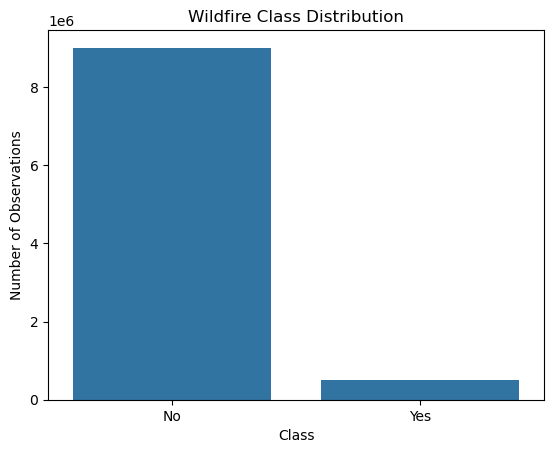

In [11]:
sns.countplot(
    data=df,
    x="Wildfire"
)

plt.title("Wildfire Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Observations")

plt.show()

# Phase 5 — Data Type Analysis

## Objective

Identify the data types of all attributes in the wildfire dataset and
categorize features into numerical, categorical, date/time, and target
variables.

In [12]:
# Display the data type of each column
df.dtypes

latitude     float64
longitude    float64
datetime      object
Wildfire      object
pr           float64
rmax         float64
rmin         float64
sph          float64
srad         float64
tmmn         float64
tmmx         float64
vs           float64
bi           float64
fm100        float64
fm1000       float64
erc          float64
etr          float64
pet          float64
vpd          float64
dtype: object

In [13]:
#Numerical Feature Distribution
#List numerical columns:

numeric_features = df.select_dtypes(
    include=np.number
).columns


numeric_features

Index(['latitude', 'longitude', 'pr', 'rmax', 'rmin', 'sph', 'srad', 'tmmn',
       'tmmx', 'vs', 'bi', 'fm100', 'fm1000', 'erc', 'etr', 'pet', 'vpd'],
      dtype='object')

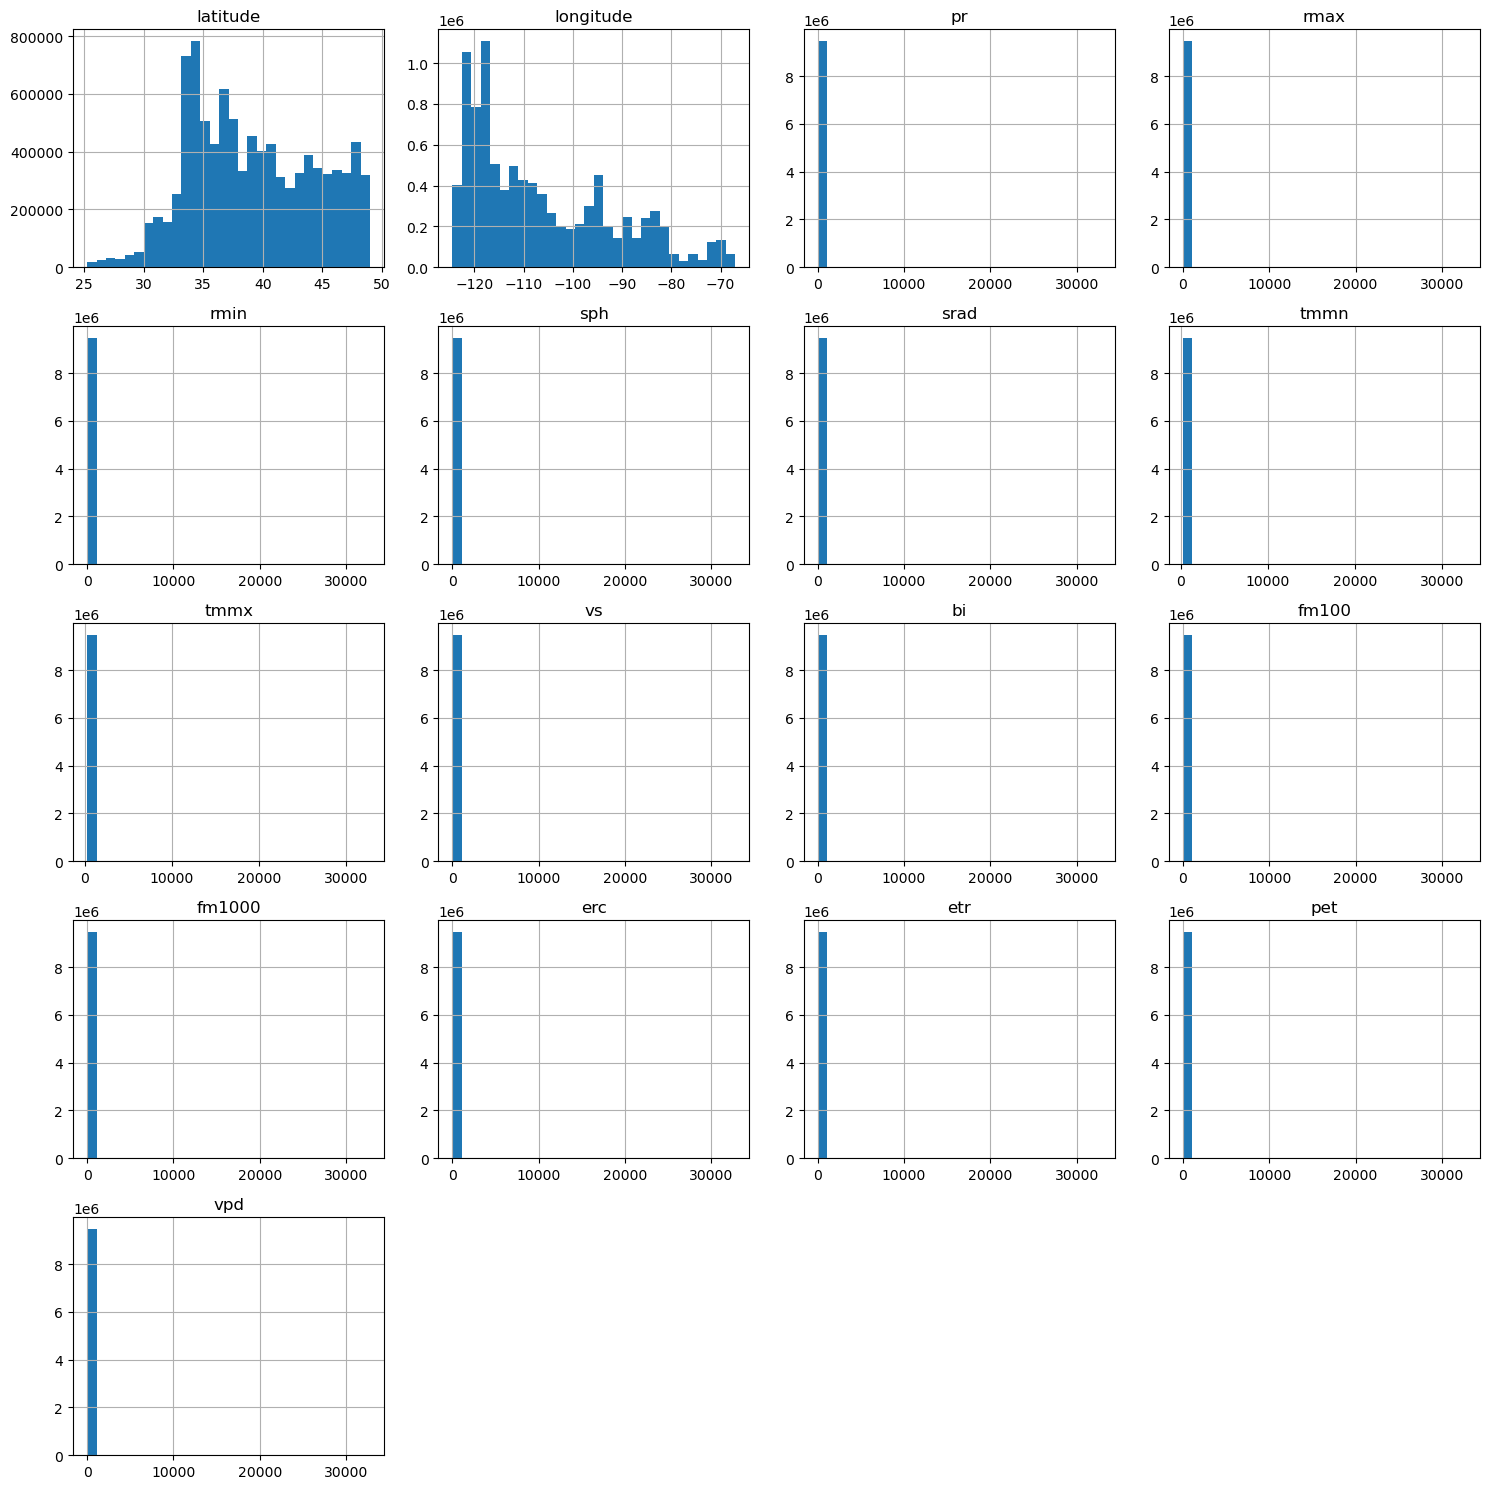

In [14]:
#histogram for each numerical feature
df[numeric_features].hist(
    figsize=(15,15),
    bins=30
)

plt.tight_layout()

plt.show()

# Phase 06 — Statistical Summary Analysis

## Objective

Analyze the statistical characteristics of numerical features to understand
their distribution, range, variation, and identify potential abnormal
values that may require further investigation during preprocessing.

In [15]:
# Generate statistical summary for numerical features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
latitude,9509925.0,39.143615,5.267332,25.26027,34.68867,38.531610,43.670042,48.99873
longitude,9509925.0,-106.434732,14.569240,-124.43700,-118.34392,-110.925833,-95.419900,-67.01250
pr,9509925.0,90.368911,1701.835716,0.00000,0.00000,0.000000,0.000000,32767.00000
rmax,9509925.0,164.575421,1698.086057,5.00000,61.80000,80.000000,95.200000,32767.00000
rmin,9509925.0,122.070653,1700.271804,1.00000,19.30000,30.800000,45.500000,32767.00000
sph,9509925.0,88.643039,1701.913860,0.00013,0.00360,0.005520,0.007790,32767.00000
srad,9509925.0,309.158711,1692.716566,0.00000,147.20000,227.700000,300.100000,32767.00000
tmmn,9509925.0,368.213687,1687.376228,230.90000,274.90000,281.100000,286.400000,32767.00000
tmmx,9509925.0,382.141498,1686.659227,241.90000,287.90000,295.500000,301.900000,32767.00000
vs,9509925.0,92.391416,1701.719467,0.30000,2.60000,3.400000,4.600000,32767.00000


In [16]:
# Check how many records contain the possible sentinel value 32767
(df == 32767).sum()

latitude         0
longitude        0
datetime         0
Wildfire         0
pr           25725
rmax         25725
rmin         25725
sph          25725
srad         25725
tmmn         25725
tmmx         25725
vs           25725
bi           25725
fm100        25725
fm1000       25725
erc          25725
etr          25725
pet          25725
vpd          25725
dtype: int64

In [17]:
# Check rows where weather data is unavailable
df[df["pr"] == 32767].head()

,latitude,longitude,datetime,Wildfire,pr,rmax,rmin,sph,srad,tmmn,tmmx,vs,bi,fm100,fm1000,erc,etr,pet,vpd
29100,42.062601,-80.953609,2017-11-17,No,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0
29101,42.062601,-80.953609,2017-11-18,No,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0
29102,42.062601,-80.953609,2017-11-19,No,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0
29103,42.062601,-80.953609,2017-11-20,No,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0
29104,42.062601,-80.953609,2017-11-21,No,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0


In [18]:
# Check rows where all environmental variables contain the sentinel value
weather_columns = [
    "pr", "rmax", "rmin", "sph", "srad",
    "tmmn", "tmmx", "vs", "bi",
    "fm100", "fm1000", "erc", "etr",
    "pet", "vpd"
]

(df[weather_columns] == 32767).all(axis=1).sum()

np.int64(25725)

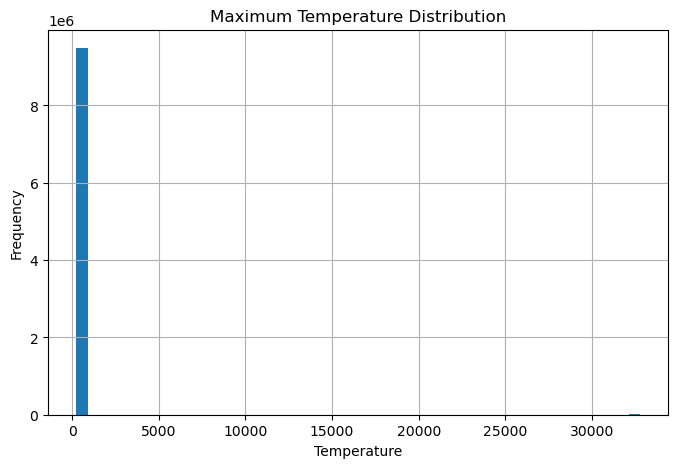

In [19]:
df["tmmx"].hist(
    bins=50,
    figsize=(8,5)
)

plt.title("Maximum Temperature Distribution")
plt.xlabel("Temperature")
plt.ylabel("Frequency")

plt.show()

# Phase 07 — Outlier Analysis

## Objective

Identify extreme values within numerical features and determine whether
they represent data errors or valid environmental conditions relevant to
wildfire prediction.

In [20]:
# Generate percentile values to identify extreme ranges
df.select_dtypes(include="number").quantile(
    [0.01, 0.05, 0.95, 0.99]
).T

,0.01,0.05,0.95,0.99
latitude,28.12528,31.426716,47.977585,48.740100
longitude,-123.65250,-122.377751,-79.170000,-69.662982
pr,0.00000,0.000000,10.700000,34.900000
rmax,25.10000,36.700000,100.000000,100.000000
rmin,4.00000,8.500000,68.200000,85.900000
sph,0.00104,0.001880,0.012870,0.017410
srad,42.30000,73.500000,348.000000,364.600000
tmmn,255.20000,265.400000,293.800000,297.900000
tmmx,267.00000,275.700000,309.000000,313.700000
vs,1.20000,1.700000,7.100000,9.500000


In [21]:
# Calculate IQR boundaries for maximum temperature
Q1 = df["tmmx"].quantile(0.25)
Q3 = df["tmmx"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound, upper_bound

(np.float64(266.9), np.float64(322.9))

In [22]:
# Calculate IQR boundaries for wind speed
Q1 = df["vs"].quantile(0.25)
Q3 = df["vs"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound, upper_bound

(np.float64(-0.399999999999999), np.float64(7.599999999999999))

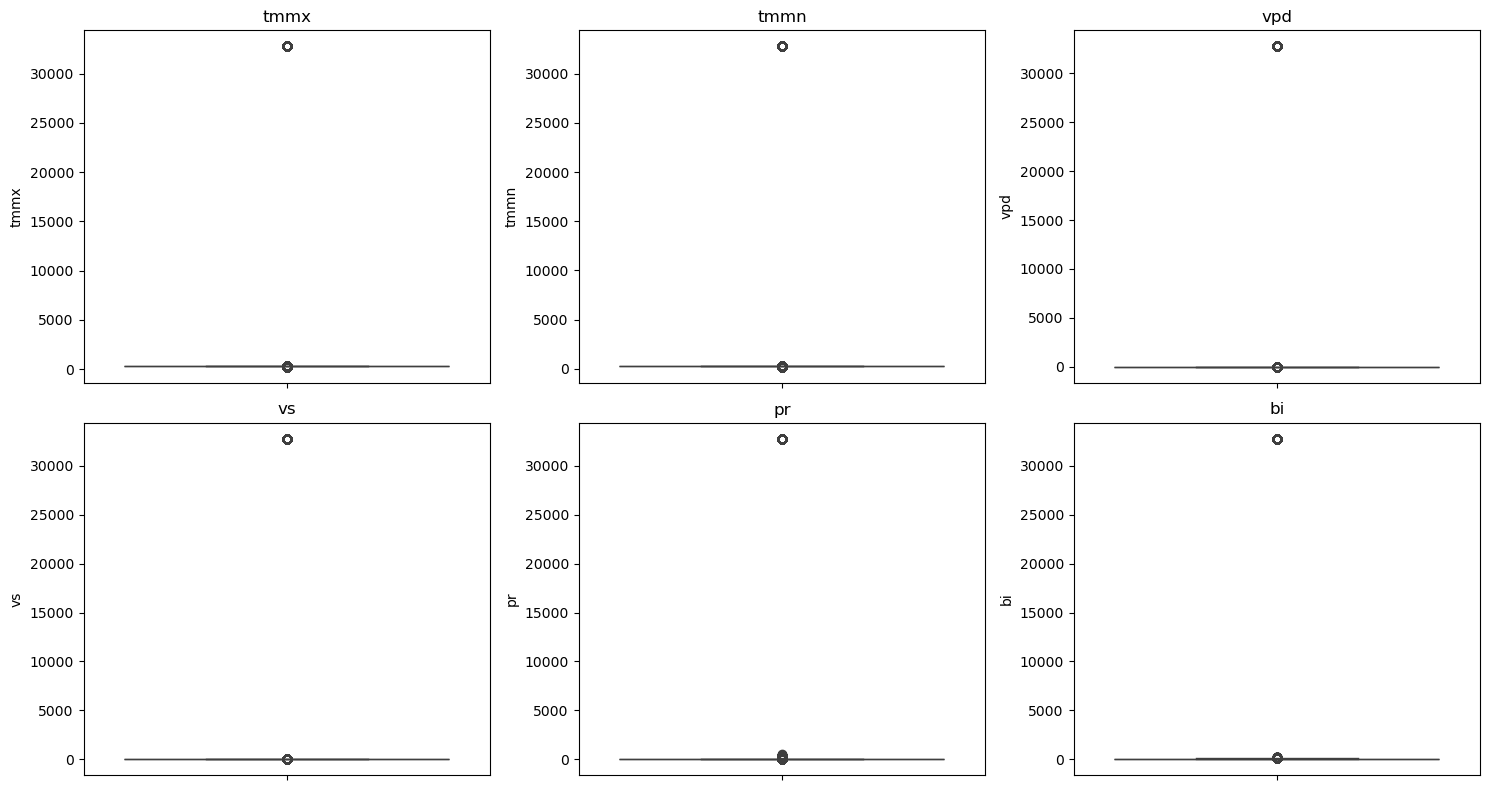

In [23]:
#outliers detection using boxplot for each numerical feature

features = [
    "tmmx",
    "tmmn",
    "vpd",
    "vs",
    "pr",
    "bi"
]


plt.figure(figsize=(15,8))


for i,col in enumerate(features):
    
    plt.subplot(2,3,i+1)
    
    sns.boxplot(
        y=df[col]
    )
    
    plt.title(col)


plt.tight_layout()

plt.show()

# Phase 08 — Feature Engineering Preparation

## Objective

Transform raw date/time information into meaningful features that can
capture seasonal and temporal patterns related to wildfire occurrence.

In [24]:
# Check the current datatype of datetime column
df["datetime"].dtype

dtype('O')

In [25]:
# Convert datetime column from string to datetime format
df["datetime"] = pd.to_datetime(df["datetime"])

In [26]:
# Confirm the datatype after conversion
df["datetime"].dtype

dtype('<M8[ns]')

In [27]:
# Check the time period covered by the dataset
df["datetime"].agg(["min", "max"])

min   2013-12-31
max   2025-04-13
Name: datetime, dtype: datetime64[ns]

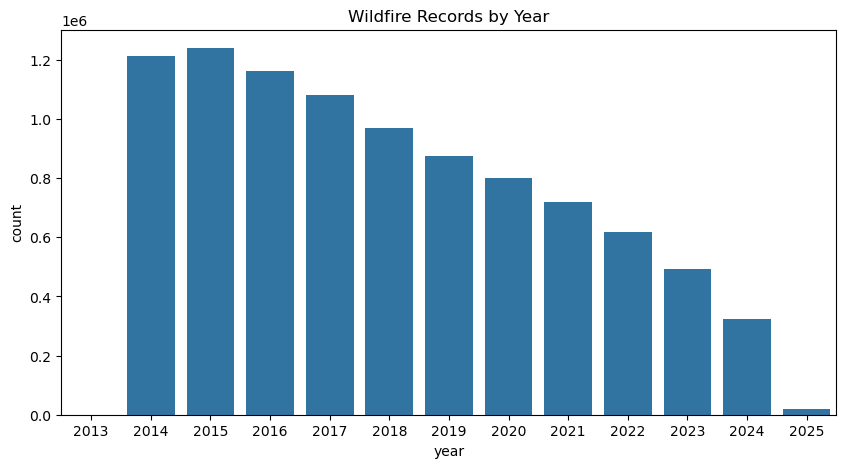

In [28]:
#create year
df["year"] = df["datetime"].dt.year

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="year"
)

plt.title(
    "Wildfire Records by Year"
)

plt.show()

In [29]:
# Check wildfire distribution across months
df.groupby(
    df["datetime"].dt.month
)["Wildfire"].value_counts()

datetime  Wildfire
1         No          572367
          Yes          31731
2         No          645730
          Yes          31299
3         No          809215
          Yes          36435
4         No          808832
          Yes          39930
5         No          877966
          Yes          44039
6         No          920754
          Yes          46952
7         No          975637
          Yes          52842
8         No          905250
          Yes          52211
9         No          778979
          Yes          46890
10        No          688271
          Yes          44446
11        No          535556
          Yes          40254
12        No          489303
          Yes          35036
Name: count, dtype: int64

# Phase 09 — Feature Relationship Analysis

## Objective

Analyze relationships between numerical features and the target variable to
identify useful predictors, understand feature dependencies, and detect
highly correlated attributes.

In [30]:
# Create temporary numerical target for correlation analysis
df["Wildfire_encoded"] = df["Wildfire"].map(
    {"No": 0, "Yes": 1}
)

In [31]:
# Check the new encoded target values
df[["Wildfire", "Wildfire_encoded"]].head()

,Wildfire,Wildfire_encoded
0,No,0
1,No,0
2,No,0
3,No,0
4,No,0


In [32]:
# Calculate correlation between numerical features and wildfire occurrence
correlation = df.select_dtypes(include="number").corr()["Wildfire_encoded"].sort_values(ascending=False)

correlation

Wildfire_encoded    1.000000
year                0.140853
erc                -0.011491
bi                 -0.011754
tmmx               -0.012093
tmmn               -0.012130
etr                -0.012253
pet                -0.012271
vpd                -0.012276
sph                -0.012296
vs                 -0.012313
srad               -0.012319
pr                 -0.012321
fm100              -0.012422
fm1000             -0.012503
rmin               -0.012672
rmax               -0.012689
latitude           -0.030539
longitude          -0.051478
Name: Wildfire_encoded, dtype: float64

In [33]:
# Check correlation between numerical features
feature_correlation = df.select_dtypes(include="number").drop(
    columns=["Wildfire_encoded"]
).corr()

feature_correlation

,latitude,longitude,pr,rmax,rmin,sph,srad,tmmn,tmmx,vs,bi,fm100,fm1000,erc,etr,pet,vpd,year
latitude,1.000000,-0.049644,0.060371,0.061846,0.061560,0.060448,0.060927,0.058872,0.058896,0.060512,0.058383,0.060690,0.060898,0.058194,0.060217,0.060301,0.060353,-0.069461
longitude,-0.049644,1.000000,0.072715,0.076203,0.075728,0.072250,0.056825,0.071282,0.070659,0.072488,0.067686,0.073458,0.073700,0.065615,0.071720,0.071864,0.072072,-0.066059
pr,0.060371,0.072715,1.000000,0.999927,0.999949,0.999993,0.998596,0.999980,0.999972,0.999993,0.999874,0.999992,0.999991,0.999876,0.999990,0.999991,0.999993,0.022205
rmax,0.061846,0.076203,0.999927,1.000000,0.999965,0.999925,0.998353,0.999896,0.999881,0.999926,0.999716,0.999950,0.999946,0.999688,0.999911,0.999916,0.999921,0.022227
rmin,0.061560,0.075728,0.999949,0.999965,1.000000,0.999942,0.998312,0.999917,0.999889,0.999944,0.999741,0.999963,0.999959,0.999721,0.999927,0.999932,0.999938,0.022286
sph,0.060448,0.072250,0.999993,0.999925,0.999942,1.000000,0.998649,0.999987,0.999982,1.000000,0.999901,0.999996,0.999995,0.999899,0.999998,0.999999,1.000000,0.022234
srad,0.060927,0.056825,0.998596,0.998353,0.998312,0.998649,1.000000,0.998778,0.998842,0.998640,0.998889,0.998556,0.998565,0.998950,0.998721,0.998706,0.998665,0.020591
tmmn,0.058872,0.071282,0.999980,0.999896,0.999917,0.999987,0.998778,1.000000,0.999996,0.999985,0.999905,0.999976,0.999976,0.999915,0.999991,0.999990,0.999988,0.022402
tmmx,0.058896,0.070659,0.999972,0.999881,0.999889,0.999982,0.998842,0.999996,1.000000,0.999980,0.999918,0.999967,0.999967,0.999930,0.999989,0.999987,0.999984,0.022291
vs,0.060512,0.072488,0.999993,0.999926,0.999944,1.000000,0.998640,0.999985,0.999980,1.000000,0.999901,0.999996,0.999995,0.999896,0.999998,0.999999,0.999999,0.022210


# Phase 10 — Data Leakage Analysis

## Objective

Identify potential data leakage risks by examining whether any attributes
contain information that would not be available during real-world wildfire
prediction.

In [34]:
# Display all dataset columns for leakage inspection
df.columns.tolist()

['latitude',
 'longitude',
 'datetime',
 'Wildfire',
 'pr',
 'rmax',
 'rmin',
 'sph',
 'srad',
 'tmmn',
 'tmmx',
 'vs',
 'bi',
 'fm100',
 'fm1000',
 'erc',
 'etr',
 'pet',
 'vpd',
 'year',
 'Wildfire_encoded']

In [35]:
# Check number of observations available for each year
df["datetime"].dt.year.value_counts().sort_index()

datetime
2013         49
2014    1213318
2015    1240064
2016    1160796
2017    1080744
2018     970501
2019     875890
2020     799530
2021     718859
2022     617160
2023     491430
2024     322374
2025      19210
Name: count, dtype: int64